# Nino3.4 SST Skill (correlation & nRMSE) & DJF Time Series

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import dask
from dask.distributed import wait

from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats
from esp_lab import psl_skill

from esp_lab.utils import spatial_utils as spatial
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mov_utils as mov
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    HADISST2_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
)

from esp_lab.utils.dask_utils import (
    DaskConfig,
    get_cluster_client,
    close_cluster,
)

from esp_lab.diagnostics import S2DDiagnostics, S2DConfig

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


In [173]:
print("xarray:", xr.__version__)
print("dask:", dask.__version__)

xarray: 2026.4.0
dask: 2026.3.0


In [174]:
# -----------------------------
# Dask setup
# -----------------------------
machine_env = os.environ.get("CLUSTER_TYPE", "local")

dask_cfg = DaskConfig(
    cluster_type=machine_env,   # "local", "slurm", "casper_pbs", or "none"
    workers=30,
    cores=4,
    memory="16GB",
    walltime="02:00:00",
    queue=None,
    project=None,
)

cluster, client = get_cluster_client(dask_cfg)

print(client)

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46485 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:45377' processes=30 threads=30, memory=502.97 GiB>


### Read in monthly SST field using I/O functions; Convert to seasonal mean

In [175]:
%%time
# =============================================================================
# CONFIGURATION BLOCK: Edit settings here
# =============================================================================

# ===== DIRECTORY AND PATHS CONFIGURATION =====
# Directories are initialized from esp_lab.paths defaults.
# Override any line below to redirect cache or output locations.
DIAG_ROOT           = S2D_DIAG_ROOT                # base diagnostics root
E3SMLE_OUTDIR       = E3SMLE_DIAG_DIR              # E3SM hindcast processed-data cache
CESM_SMYLE_OUTDIR   = CESM_SMYLE_DIAG_DIR          # CESM-SMYLE processed-data cache
NMME_OUTDIR         = NMME_DIAG_DIR                # NMME processed-data cache

# Optional NMME overlay. NMME is added only when this is True and the
# required NMME SST-index time-series files exist.
include_nmme = False
nmme_data_start = 1980
nmme_data_end = 2020

# Post-processed raw model data directory (E3SM time-series files).
# First existing path wins; falls back to the first candidate if none exist.
DATA_DIR_CANDIDATES = [
    "/global/cfs/cdirs/e3sm/S2S2D/post_process",
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if os.path.exists(p)), DATA_DIR_CANDIDATES[0])

# ===== FIELD CONFIGURATION =====
field = "TS"

# ===== MULTI-CASE E3SM HINDCAST CONFIGURATION =====
# Add or comment out entries here as new hindcasts become available under DATA_DIR.
# Each case uses its own cache_tag subdirectory under E3SMLE_OUTDIR.
E3SM_CASES = {
    "E3SM-FOSIRL": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag":   "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
        "color":       "k",
        "linestyle":   "-",
    },
    "E3SM-Reanalysis": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag":   "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
        "color":       "tab:blue",
        "linestyle":   "-",
    },
#    "E3SM-4DEnVarOcn": {
#        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
#        "cache_tag":   "4DEnVarOcn",
#        "display_name": "E3SMv3-4DEnVarOcn",
#        "color":       "tab:purple",
#        "linestyle":   "-",
#    },
}

# Primary / reference case for single-case backward-compatible variables
E3SM_REFERENCE_CASE = "E3SM-FOSIRL"

# Derived reference-case values used by S2DConfig and downstream cells
_ref = E3SM_CASES[E3SM_REFERENCE_CASE]
case_prefix = _ref["case_prefix"]
# Reference-case cache root. The loader below resolves per-case and legacy flat layouts.
outdir = str(E3SMLE_OUTDIR)

# ===== ENSEMBLE AND HINDCAST PARAMETERS =====
case_nens  = 10
case_nlead = 24

force_rewrite = True

members = [f"EN{i:02d}" for i in range(case_nens)]

years  = 1980
yeare  = 2018
yexcl  = None

# Drift / skill climatology years
climy0 = 1980
climy1 = 2010

init_months = [5, 11]
init_years = {
    5:  [y for y in np.arange(years, yeare + 1) if y != yexcl],
    11: [y for y in np.arange(years, yeare + 1) if y != yexcl],
}

# ===== REGION CONFIGURATION =====
# Regional coordinates mapping for the 13 indices
REGIONS_COORDS = {
    "Nino12":      [270.0, 280.0, -10.0,  0.0],
    "Nino3":       [210.0, 270.0,  -5.0,  5.0],
    "Nino3.4":     [190.0, 240.0,  -5.0,  5.0],
    "Nino4":       [160.0, 210.0,  -5.0,  5.0],
    "TNA":         [305.0, 345.0,   5.0, 25.0],
    "TSA":         [330.0,  10.0, -20.0,  0.0],
    "PACWRAMPOOL": [ 60.0, 170.0, -15.0, 15.0],
    "AtlNino":     [340.0, 360.0,  -3.0,  3.0],
    "AtlMDR":      [280.0, 350.0,  10.0, 20.0],
    "IOD":         [ 50.0, 110.0, -10.0, 10.0],
    "TNI":         [160.0, 280.0, -10.0, 10.0],
    "ONI":         [190.0, 240.0,  -5.0,  5.0],
    "RONI":        [190.0, 240.0, -20.0, 20.0],
}

region_name = "Nino3.4"  # change to any key in REGIONS_COORDS
region      = REGIONS_COORDS.get(region_name, [])

# Y-axis range configurations for each region/index
REGIONS_PLOT_SETTINGS = {
    "Nino12":      {"acc_lim": [0.0, 1.0], "rmse_lim": [0.1, 1.8], "ts_lim": [-4.0, 4.0], "ts_yticks": [-4, -2, 0, 2, 4]},
    "Nino3":       {"acc_lim": [0.0, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-4.0, 4.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "Nino3.4":     {"acc_lim": [0.0, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-4.0, 4.0], "ts_yticks": [-3.0, -1.5, 0, 1.5, 3]},
    "Nino4":       {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "TNA":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "TSA":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "PACWRAMPOOL": {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "AtlNino":     {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "AtlMDR":      {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "IOD":         {"acc_lim": [-0.3, 0.9], "rmse_lim": [0.1, 2.0], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "TNI":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.8], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "ONI":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "RONI":        {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.1, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
}

plot_settings = REGIONS_PLOT_SETTINGS.get(region_name, {
    "acc_lim":  [-0.2, 1.0],
    "rmse_lim": [0.2, 1.5],
    "ts_lim":   [-3.0, 3.0],
    "ts_yticks": [-3, -1.5, 0, 1.5, 3]
})

# ===== DATA ACCESS OPTIONS =====
realm   = "atm"
grid    = "180x360_aave"
freq    = "monthly"
ts_split = "2yr"
engine  = "netcdf4"

# Keep open-time chunking light/safe
chunks = {}

# Use this after data are combined, before heavy operations
mchunk = {
    "Y":   3,
    "L":   24,
    "M":   2,
    "lat": 90,
    "lon": 180,
}

require_all_members   = True
verify_field_name     = True
verify_coverage       = True
persist_intermediate  = True
load_regional_series  = True
convert_ts_to_degC    = True

# ===== END CONFIGURATION BLOCK =====

# Build the reference-case S2DConfig (used by all single-case variables and diag)
cfg = S2DConfig(
    field=field,
    data_dir=DATA_DIR,
    case_prefix=case_prefix,
    members=members,
    nlead=case_nlead,
    init_months=init_months,
    init_years=init_years,
    region=region,
    region_name=region_name,
    climy0=climy0,
    climy1=climy1,
    outdir=outdir,
    force_rewrite=force_rewrite,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    engine=engine,
    chunks=chunks,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    persist_intermediate=persist_intermediate,
    load_regional_series=load_regional_series,
    convert_ts_to_degC=convert_ts_to_degC,
)

print(f"Active E3SM cases: {list(E3SM_CASES.keys())}")
print(f"Reference case:    {E3SM_REFERENCE_CASE}")
print(f"DATA_DIR:          {DATA_DIR}")
print(f"E3SMLE_OUTDIR:     {E3SMLE_OUTDIR}")
print(f"CESM_SMYLE_OUTDIR: {CESM_SMYLE_OUTDIR}")
print(f"FIGURE_OUTDIR:     {FIGURE_OUTDIR}")
print(cfg)


Active E3SM cases: ['E3SM-FOSIRL', 'E3SM-Reanalysis']
Reference case:    E3SM-FOSIRL
DATA_DIR:          /global/cfs/cdirs/e3sm/S2S2D/post_process
E3SMLE_OUTDIR:     /global/cfs/cdirs/e3sm/zhan391/s2d_diag/E3SMLE
CESM_SMYLE_OUTDIR: /global/cfs/cdirs/e3sm/zhan391/s2d_diag/CESM-SMYLE
FIGURE_OUTDIR:     /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag
S2DConfig(field='TS', case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', data_dir='/global/cfs/cdirs/e3sm/S2S2D/post_process', members=['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09'], nlead=24, init_months=[5, 11], init_years={5: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.in

In [ ]:
%%time
# -----------------------------
# Load preprocessed E3SM regional SST index (all cases)
# -----------------------------
results_by_case = {}
cfg_by_case = {}
diag_by_case = {}
skipped_e3sm_cases = {}


def _regional_cache_file(case_key, case_info, month, freq_tag):
    filename = f"E3SMLE{month:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{region_name}SST_{freq_tag}.nc"
    case_file = E3SMLE_OUTDIR / case_info["cache_tag"] / "sst_index" / "timeseries" / filename
    if case_file.is_file():
        return case_file
    return None


def _missing_sst_cache_message(case_key, case_info, expected):
    return (
        f"missing preprocessed regional SST cache for {case_key}; expected {expected}. "
        "Run jupyter/0_run_sigmod_sst_index.ipynb, or run scripts/run_process_sst_index.py "
        f"for case_prefix={case_info['case_prefix']!r}, "
        f"and write the output under {E3SMLE_OUTDIR / case_info['cache_tag'] / 'sst_index' / 'timeseries'}. "
        "Then rerun this plot notebook."
    )


for case_key, case_info in E3SM_CASES.items():
    first_mon = _regional_cache_file(case_key, case_info, init_months[0], "mon")
    if first_mon is None:
        expected = E3SMLE_OUTDIR / case_info["cache_tag"] / "sst_index" / "timeseries" / f"E3SMLE{init_months[0]:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{region_name}SST_mon.nc"
        skipped_e3sm_cases[case_key] = _missing_sst_cache_message(case_key, case_info, expected)
        print(f"[{case_key}] skipped: {skipped_e3sm_cases[case_key]}")
        continue

    case_outdir = str(first_mon.parent)
    case_cfg = S2DConfig(
        field=field,
        data_dir=DATA_DIR,
        case_prefix=case_info["case_prefix"],
        members=members,
        nlead=case_nlead,
        init_months=init_months,
        init_years=init_years,
        region=region,
        region_name=region_name,
        climy0=climy0,
        climy1=climy1,
        outdir=case_outdir,
        force_rewrite=force_rewrite,
        realm=realm,
        grid=grid,
        freq=freq,
        ts_split=ts_split,
        engine=engine,
        chunks=chunks,
        require_all_members=require_all_members,
        verify_field_name=verify_field_name,
        verify_coverage=verify_coverage,
        persist_intermediate=persist_intermediate,
        load_regional_series=load_regional_series,
        convert_ts_to_degC=convert_ts_to_degC,
    )

    case_results = {}
    for m in case_cfg.init_months:
        outfile_mon  = _regional_cache_file(case_key, case_info, m, "mon")
        outfile_seas = _regional_cache_file(case_key, case_info, m, "seas")
        missing = []
        if outfile_mon is None:
            missing.append(("monthly", "mon"))
        if outfile_seas is None:
            missing.append(("seasonal", "seas"))
        if missing:
            missing_names = "/".join(name for name, _ in missing)
            _, freq_tag = missing[0]
            expected = E3SMLE_OUTDIR / case_info["cache_tag"] / "sst_index" / "timeseries" / f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{region_name}SST_{freq_tag}.nc"
            raise FileNotFoundError(
                _missing_sst_cache_message(case_key, case_info, expected)
                + f" Missing {missing_names} cache for month={m}."
            )

        ds_mon  = xr.open_dataset(outfile_mon)
        ds_seas = xr.open_dataset(outfile_seas)

        case_results[m] = {
            "mon":      ds_mon["sst"].load(),
            "seas":     ds_seas["sst"].load(),
            "time_mon": ds_mon["time"].load(),
            "time_seas": ds_seas["time"].load(),
        }
        print(f"[{case_key}] month={m}: loaded {outfile_mon}")

    case_diag = S2DDiagnostics(
        cfg=case_cfg,
        data_access=data_access,
        obs_access=obs_access,
        stats=stats,
        spatial=spatial,
        cal=cal,
    )

    results_by_case[case_key] = case_results
    cfg_by_case[case_key]     = case_cfg
    diag_by_case[case_key]    = case_diag

E3SM_ACTIVE_CASES = {case_key: E3SM_CASES[case_key] for case_key in results_by_case}
if E3SM_REFERENCE_CASE not in results_by_case:
    raise FileNotFoundError(
        f"Reference case {E3SM_REFERENCE_CASE!r} was not loaded. "
        f"Skipped cases: {skipped_e3sm_cases}"
    )

print(f"Loaded E3SM cases: {list(E3SM_ACTIVE_CASES)}")
if skipped_e3sm_cases:
    print(f"Skipped E3SM cases: {skipped_e3sm_cases}")

# Backward-compatible reference-case aliases
results = results_by_case[E3SM_REFERENCE_CASE]
cfg     = cfg_by_case[E3SM_REFERENCE_CASE]
diag    = diag_by_case[E3SM_REFERENCE_CASE]


In [ ]:
# -----------------------------
# Load fixed landmask
# -----------------------------
# Fixed masks live with the reference E3SM case in the model-first cache.
outdir = str(E3SMLE_OUTDIR / E3SM_CASES[E3SM_REFERENCE_CASE]["cache_tag"] / "sst_index" / "timeseries")
shared_outdir = outdir
fixed_dir = str(E3SMLE_OUTDIR / E3SM_CASES[E3SM_REFERENCE_CASE]["cache_tag"] / "fixed")
landmask_file = os.path.join(fixed_dir, "sftlf.E3SM.nc")
landmask = xr.open_dataarray(landmask_file)


In [178]:
# -----------------------------
# Verify saved model regional series (optional sanity check)
# -----------------------------
for m in cfg.init_months:
    for freq_tag in ["seas", "mon"]:
        outfile = os.path.join(
            outdir,
            f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_{freq_tag}.nc"
        )

        if not os.path.exists(outfile):
            print(f"[WARNING] Missing file: {outfile}")
            continue

        with xr.open_dataset(outfile) as ds:
            print(f"\nmonth={m}, freq={freq_tag}")
            print(ds)

            # quick sanity checks
            if "sst" in ds:
                print(
                    "  sst min/max:",
                    float(ds["sst"].min()),
                    float(ds["sst"].max())
                )
                print("  units:", ds["sst"].attrs.get("units", "N/A"))
                


month=5, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39, L: 8, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 25kB ...
    time     (Y, L) object 2kB ...
  sst min/max: 19.465014364430324 29.677032837211915
  units: degC

month=5, freq=mon
<xarray.Dataset> Size: 84kB
Dimensions:  (Y: 39, L: 24, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 75kB ...
    time     (Y, L) object 7kB ...
  sst min/max: 19.383359552981055 29.793730417904694
  units: degC

month=11, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39, 

In [ ]:
%%time
# -----------------------------
# Load preprocessed HadISST2 and packaged PSL observational SST indices
# -----------------------------
obs_fixed_dir = str(HADISST2_DIAG_DIR / "fixed")
obs_sst_dir = str(HADISST2_DIAG_DIR / "sst_index" / "timeseries")
obs_mask_file = os.path.join(obs_fixed_dir, "sftlf.HadISST2.nc")
landmasko = xr.open_dataarray(obs_mask_file)

outfile_mon = os.path.join(obs_sst_dir, f"HadISST2_sst_{cfg.region_name}SST_mon.nc")
outfile_seas = os.path.join(obs_sst_dir, f"HadISST2_sst_{cfg.region_name}SST_seas.nc")

obs_mon = xr.open_dataset(outfile_mon)["sst"].load()
obs_seas = xr.open_dataset(outfile_seas)["sst"].load()

# PSL CSV indices are packaged in external/. They are anomaly indices, so they
# are used as a sensitivity reference rather than replacing the local HadISST2 target.
psl_mon = psl_skill.psl_reference(cfg.region_name, seasonal=False)
psl_seas = psl_skill.psl_reference(cfg.region_name, seasonal=True)

obs_agreement_mon = psl_skill.observation_agreement(
    obs_mon,
    psl_mon,
    climy0,
    climy1,
)
obs_agreement_seas = psl_skill.observation_agreement(
    obs_mon,
    psl_mon,
    climy0,
    climy1,
    seasonal=True,
)

print("Obs Mon index:")
print(obs_mon)
print("\nObs Seas index:")
print(obs_seas)
print("\nPSL Mon index:")
print(psl_mon)
print("\nPSL Seas index:")
print(psl_seas)
print("\nHadISST2-derived vs PSL monthly agreement:")
print(obs_agreement_mon)
print("\nHadISST2-derived vs PSL seasonal agreement:")
print(obs_agreement_seas)


In [180]:
%%time
# -----------------------------
# Drift removal (all cases)
# -----------------------------
results_dd_by_case = {}

for case_key in E3SM_ACTIVE_CASES:
    case_diag    = diag_by_case[case_key]
    case_results = results_by_case[case_key]
    results_dd_by_case[case_key] = case_diag.remove_drift_for_results(case_results)

# Backward-compatible reference-case aliases
results_dd = results_dd_by_case[E3SM_REFERENCE_CASE]

regsst_dd      = {}
regsst_drift   = {}
seas_regsst_dd    = {}
seas_regsst_drift = {}

for m in cfg.init_months:
    regsst_dd[m]         = results_dd[m]["mon_dd"]
    regsst_drift[m]      = results_dd[m]["mon_drift"]
    seas_regsst_dd[m]    = results_dd[m]["seas_dd"]
    seas_regsst_drift[m] = results_dd[m]["seas_drift"]

# convenient reference-case access
e3smle05_regsst_dd    = regsst_dd.get(5)
e3smle11_regsst_dd    = regsst_dd.get(11)
e3smle05_seas_regsst_dd = seas_regsst_dd.get(5)
e3smle11_seas_regsst_dd = seas_regsst_dd.get(11)


CPU times: user 17.5 ms, sys: 2.72 ms, total: 20.2 ms
Wall time: 19 ms


In [181]:
%%time
# -----------------------------
# Skill computation (all cases) against HadISST2 plus packaged PSL sensitivity reference
# -----------------------------
reference_mon = {
    "HadISST2": (obs_mon, False),
    "PSL":      (psl_mon, True),
}
reference_seas = {
    "HadISST2": (obs_seas, False),
    "PSL":      (psl_seas, True),
}

results_skill_by_case = {}

for case_key in E3SM_ACTIVE_CASES:
    case_cfg        = cfg_by_case[case_key]
    case_results    = results_by_case[case_key]
    case_results_dd = results_dd_by_case[case_key]
    case_skill      = {}

    for m in case_cfg.init_months:
        skill_ref_mon = psl_skill.compute_reference_skill(
            case_results_dd[m]["mon_dd"],
            case_results[m]["time_mon"],
            reference_mon,
            climy0,
            climy1,
            nleads=case_cfg.nlead,
            detrend=True,
            monthly=True,
        ).load()
        skill_ref_seas = psl_skill.compute_reference_skill(
            case_results_dd[m]["seas_dd"],
            case_results[m]["time_seas"],
            reference_seas,
            climy0,
            climy1,
            nleads=case_cfg.seasonal_nlead,
            detrend=True,
            monthly=False,
        ).load()

        skill_ref_mon  = psl_skill.add_reference_sensitivity(skill_ref_mon)
        skill_ref_seas = psl_skill.add_reference_sensitivity(skill_ref_seas)

        case_skill[m] = {
            "skill_mon":     skill_ref_mon.sel(reference="HadISST2"),
            "skill_seas":    skill_ref_seas.sel(reference="HadISST2"),
            "skill_ref_mon":  skill_ref_mon,
            "skill_ref_seas": skill_ref_seas,
        }

    results_skill_by_case[case_key] = case_skill

# Backward-compatible reference-case aliases
results_skill = results_skill_by_case[E3SM_REFERENCE_CASE]

skill_mon  = {m: results_skill[m]["skill_mon"]  for m in cfg.init_months}
skill_seas = {m: results_skill[m]["skill_seas"] for m in cfg.init_months}

e3smle_skill_ref_mon  = {m: results_skill[m]["skill_ref_mon"]  for m in cfg.init_months}
e3smle_skill_ref_seas = {m: results_skill[m]["skill_ref_seas"] for m in cfg.init_months}

e3smle05_skill      = skill_mon.get(5)
e3smle11_skill      = skill_mon.get(11)
e3smle05_seas_skill = skill_seas.get(5)
e3smle11_seas_skill = skill_seas.get(11)


CPU times: user 5.54 s, sys: 1.4 s, total: 6.94 s
Wall time: 5.99 s


In [182]:
# -----------------------------
# Combine skill arrays for plotting (all cases)
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

e3smle_skill_by_case      = {}
e3smle_seas_skill_by_case = {}
e3smle_skill_ref_by_case      = {}
e3smle_seas_skill_ref_by_case = {}

for case_key in E3SM_ACTIVE_CASES:
    case_skill = results_skill_by_case[case_key]
    e3smle_skill_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_mon"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_seas_skill_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_seas"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_skill_ref_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_ref_mon"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_seas_skill_ref_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_ref_seas"] for m in cfg.init_months], dim=startmonth
    )

# Backward-compatible reference-case aliases
e3smle_skill          = e3smle_skill_by_case[E3SM_REFERENCE_CASE]
e3smle_seas_skill     = e3smle_seas_skill_by_case[E3SM_REFERENCE_CASE]
e3smle_skill_ref      = e3smle_skill_ref_by_case[E3SM_REFERENCE_CASE]
e3smle_seas_skill_ref = e3smle_seas_skill_ref_by_case[E3SM_REFERENCE_CASE]

print(e3smle_skill)
print(e3smle_seas_skill)


<xarray.Dataset> Size: 6kB
Dimensions:      (startmonth: 2, L: 24)
Coordinates:
  * startmonth   (startmonth) int64 16B 5 11
  * L            (L) int64 192B 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
    reference    <U8 32B 'HadISST2'
Data variables: (12/15)
    corr         (startmonth, L) float64 384B 0.9296 0.8917 ... 0.1807 0.1432
    pval         (startmonth, L) float64 384B 3.484e-17 2.653e-14 ... 0.3845
    rmse         (startmonth, L) float64 384B 0.3927 0.7028 ... 1.097 1.095
    msss         (startmonth, L) float64 384B 0.8458 0.506 ... -0.2045 -0.1998
    rpc          (startmonth, L) float64 384B 0.9309 0.9116 ... 0.3101 0.258
    sig_obs      (startmonth, L) float64 384B 0.614 0.6158 ... 0.8625 1.054
    ...           ...
    dacc_ref     (startmonth, L) float64 384B 0.01659 0.005325 ... -0.01549
    corr_mean    (startmonth, L) float64 384B 0.9379 0.8944 ... 0.1537 0.1354
    corr_robust  (startmonth, L) float64 384B 0.9296 0.8917 ... 0.1267 0.1277
    dnrmse_ref   

### CESM-SMYLE benchmark comparison

This section follows the CESM-SMYLE benchmark workflow used in the skill-map notebooks, but applies it to the selected regional SST index:

- load preprocessed CESM-SMYLE regional index files,
- remove lead-dependent drift using the same climatology window,
- compute seasonal ACC/nRMSE skill against HadISST2,
- compute the same skill against the packaged NOAA PSL index as a sensitivity reference,
- make both references available for the skill and DJF time-series plots.

**Significance interpretation:** filled ACC markers in the skill plot use each model's
correlation p-value against the null hypothesis of zero correlation. They do not test
whether E3SMLE is significantly better than CESM-SMYLE. A between-model superiority
claim would require the matched-ensemble resampling used in the map notebooks, applied
separately to ACC and nRMSE on the common verification years.

In [ ]:
%%time
# -----------------------------
# Load preprocessed CESM-SMYLE seasonal regional SST index
# -----------------------------
from esp_lab import data_access_cesm_smyle as smyle_access

SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
smyle_outdir = os.path.join(SMYLE_BENCHMARK_DIR, "sst_index", "timeseries")
smyle_nens = 20
smyle_nlead = case_nlead

smyle_seas_reg_by_month = {}
smyle_time_by_month = {}

for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_seas.nc",
    )
    
    ds_idx = xr.open_dataset(smyle_index_file).load()
    smyle_seas_reg_by_month[m] = ds_idx["sst"]
    smyle_time_by_month[m] = ds_idx["time"]
    print(f"Loaded cached CESM-SMYLE regional index: {smyle_index_file}")

# Remove CESM-SMYLE drift using the same climatology window.
smyle_seas_dd_by_month = {}
smyle_seas_drift_by_month = {}

for m in cfg.init_months:
    smyle_seas_dd_by_month[m], smyle_seas_drift_by_month[m] = stats.remove_drift(
        smyle_seas_reg_by_month[m],
        smyle_time_by_month[m],
        climy0,
        climy1,
    )

# Compute CESM-SMYLE seasonal skill against both observational references.
smyle_skill_ref_seas = {}
smyle_skill_seas = {}
smyle_skill_detrend = True

for m in cfg.init_months:
    model_anom = smyle_seas_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
    model_time = smyle_time_by_month[m]

    skill_ref = psl_skill.compute_reference_skill(
        model_anom,
        model_time,
        reference_seas,
        climy0,
        climy1,
        nleads=cfg.seasonal_nlead,
        resamp=0,
        detrend=smyle_skill_detrend,
        monthly=False,
    ).load()
    skill_ref = psl_skill.add_reference_sensitivity(skill_ref)

    smyle_skill_ref_seas[m] = skill_ref
    smyle_skill_seas[m] = skill_ref.sel(reference="HadISST2")

# Combine CESM-SMYLE data for plotting
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")
smyle_seas = xr.concat(
    [smyle_seas_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_seas_time = xr.concat(
    [smyle_time_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_seas_skill_plot = xr.concat(
    [smyle_skill_seas[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_seas_skill_ref = xr.concat(
    [smyle_skill_ref_seas[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

In [ ]:
%%time
# -----------------------------
# Load preprocessed CESM-SMYLE monthly index and compute monthly skill
# -----------------------------
smyle_reg_by_month = {}
smyle_time_mon_by_month = {}
smyle_dd_by_month = {}
smyle_drift_by_month = {}
smyle_skill_mon = {}
smyle_skill_ref_mon = {}
smyle_skill_mon_detrend = True

for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_mon.nc",
    )
    
    ds_idx = xr.open_dataset(smyle_index_file).load()
    smyle_reg_by_month[m] = ds_idx["sst"]
    smyle_time_mon_by_month[m] = ds_idx["time"]
    print(f"Loaded cached CESM-SMYLE monthly regional index: {smyle_index_file}")

    # Remove monthly lead-dependent drift
    smyle_dd_by_month[m], smyle_drift_by_month[m] = stats.remove_drift(
        smyle_reg_by_month[m],
        smyle_time_mon_by_month[m],
        climy0,
        climy1,
    )

    model_anom = smyle_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
    model_time = smyle_time_mon_by_month[m]

    skill_ref = psl_skill.compute_reference_skill(
        model_anom,
        model_time,
        reference_mon,
        climy0,
        climy1,
        nleads=cfg.nlead,
        resamp=0,
        detrend=smyle_skill_mon_detrend,
        monthly=True,
    ).load()
    skill_ref = psl_skill.add_reference_sensitivity(skill_ref)

    smyle_skill_ref_mon[m] = skill_ref
    smyle_skill_mon[m] = skill_ref.sel(reference="HadISST2")

# Combine monthly CESM-SMYLE skill
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")
smyle = xr.concat(
    [smyle_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_time = xr.concat(
    [smyle_time_mon_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_skill_plot = xr.concat(
    [smyle_skill_mon[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_skill_ref = xr.concat(
    [smyle_skill_ref_mon[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)

In [ ]:
# -----------------------------
# Optional NMME benchmark skill
# -----------------------------
# NMME SST-index time series are generated by jupyter/0_run_nmme_sst_index.ipynb.
# This notebook computes/saves NMME SST-index skill only when include_nmme=True
# and the required NMME time-series files already exist.
nmme_label = "NMME"
nmme_skill_available = False
NMME_PERIOD_TAG = f"{nmme_data_start}_{nmme_data_end}"
NMME_SKILL_DIR = NMME_OUTDIR / "sst_index" / "skill"
NMME_TIMESERIES_DIR = NMME_OUTDIR / "sst_index" / "timeseries"
nmme_region_token = cfg.region_name.replace(".", "")
nmme_index_label = "ELI" if cfg.region_name == "ELI" else f"{nmme_region_token}SST"
NMME_SKILL_FILE = NMME_SKILL_DIR / f"NMME_{nmme_region_token}_skill_{NMME_PERIOD_TAG}.nc"

for _nmme_name in [
    "nmme_skill_ds",
    "nmme_seas_skill_plot",
    "nmme_seas_skill_spread",
    "nmme_skill_plot",
    "nmme_skill_spread",
    "nmme",
    "nmme_time",
    "nmme_seas",
    "nmme_seas_time",
]:
    globals().pop(_nmme_name, None)


def _nmme_timeseries_file(init_month, freq_tag):
    return NMME_TIMESERIES_DIR / f"NMME{init_month:02d}_{nmme_index_label}_{freq_tag}_dd_{NMME_PERIOD_TAG}.nc"


def _write_nmme_skill_file(skill):
    NMME_SKILL_DIR.mkdir(parents=True, exist_ok=True)
    skill_ds = xr.Dataset()
    for name, ds in skill.items():
        lead_dim = "seasonal_L" if "seas" in name else "monthly_L"
        ds_out = ds.rename({"L": lead_dim}) if "L" in ds.dims else ds
        for var in ds.data_vars:
            skill_ds[f"{name}_{var}"] = ds_out[var]
    skill_ds.attrs.update(
        {
            "description": f"NMME {cfg.region_name} skill diagnostics computed by 4_refactor_sst_skill_ts.ipynb",
            "region": cfg.region_name,
            "data_start": nmme_data_start,
            "data_end": nmme_data_end,
            "source_timeseries_dir": str(NMME_TIMESERIES_DIR),
            "reference": "HadISST2",
        }
    )
    skill_ds.to_netcdf(NMME_SKILL_FILE)
    return skill_ds


if include_nmme:
    nmme_startmonths = []
    missing_nmme_files = []
    nmme_dd_by_month = {}
    nmme_time_by_month = {}
    nmme_seas_dd_by_month = {}
    nmme_seas_time_by_month = {}

    for m in cfg.init_months:
        mon_file = _nmme_timeseries_file(m, "mon")
        seas_file = _nmme_timeseries_file(m, "seas")
        if not mon_file.is_file() or not seas_file.is_file():
            missing_nmme_files.extend([str(path) for path in [mon_file, seas_file] if not path.is_file()])
            continue

        mon_ds = xr.open_dataset(mon_file).load()
        seas_ds = xr.open_dataset(seas_file).load()
        nmme_dd_by_month[m] = mon_ds["sst"]
        nmme_time_by_month[m] = mon_ds["time"]
        nmme_seas_dd_by_month[m] = seas_ds["sst"]
        nmme_seas_time_by_month[m] = seas_ds["time"]
        nmme_startmonths.append(m)

    if nmme_startmonths:
        nmme_skill = {}
        nmme_skill_mmm = {}
        nmme_seas_skill = {}
        nmme_seas_skill_mmm = {}

        for m in nmme_startmonths:
            nmme_seas_skill[m] = stats.compute_skill_seasonal(
                nmme_seas_dd_by_month[m],
                nmme_seas_time_by_month[m],
                obs_seas,
                climy0,
                climy1,
                nleads=min(cfg.seasonal_nlead, nmme_seas_dd_by_month[m].sizes.get("L", cfg.seasonal_nlead)),
                resamp=0,
                detrend=True,
                monthly=False,
            ).load()
            nmme_seas_skill_mmm[m] = stats.compute_skill_seasonal(
                nmme_seas_dd_by_month[m].mean("M").rename({"model": "M"}),
                nmme_seas_time_by_month[m],
                obs_seas,
                climy0,
                climy1,
                nleads=min(cfg.seasonal_nlead, nmme_seas_dd_by_month[m].sizes.get("L", cfg.seasonal_nlead)),
                resamp=0,
                detrend=True,
                monthly=False,
            ).load()
            nmme_skill[m] = stats.compute_skill_seasonal(
                nmme_dd_by_month[m],
                nmme_time_by_month[m],
                obs_mon,
                climy0,
                climy1,
                nleads=min(cfg.nlead, nmme_dd_by_month[m].sizes.get("L", cfg.nlead)),
                resamp=0,
                detrend=True,
                monthly=True,
            ).load()
            nmme_skill_mmm[m] = stats.compute_skill_seasonal(
                nmme_dd_by_month[m].mean("M").rename({"model": "M"}),
                nmme_time_by_month[m],
                obs_mon,
                climy0,
                climy1,
                nleads=min(cfg.nlead, nmme_dd_by_month[m].sizes.get("L", cfg.nlead)),
                resamp=0,
                detrend=True,
                monthly=True,
            ).load()

        nmme_startmonth = xr.DataArray(nmme_startmonths, name="startmonth", dims="startmonth")
        nmme_skill_ds = _write_nmme_skill_file(
            {
                "nmme_seas_skill": xr.concat([nmme_seas_skill[m] for m in nmme_startmonths], dim=nmme_startmonth),
                "nmme_seas_skill_mmm": xr.concat([nmme_seas_skill_mmm[m] for m in nmme_startmonths], dim=nmme_startmonth),
                "nmme_skill": xr.concat([nmme_skill[m] for m in nmme_startmonths], dim=nmme_startmonth),
                "nmme_skill_mmm": xr.concat([nmme_skill_mmm[m] for m in nmme_startmonths], dim=nmme_startmonth),
            }
        ).load()

        def _nmme_var(var_name, lead_dim):
            da = nmme_skill_ds[var_name]
            if lead_dim in da.dims:
                da = da.rename({lead_dim: "L"})
            return da

        nmme_seas_skill_plot = xr.Dataset(
            {
                "corr": _nmme_var("nmme_seas_skill_mmm_corr", "seasonal_L"),
                "pval": _nmme_var("nmme_seas_skill_mmm_pval", "seasonal_L"),
                "rmse": _nmme_var("nmme_seas_skill_mmm_rmse", "seasonal_L"),
            }
        )
        nmme_seas_skill_spread = xr.Dataset(
            {
                "corr": _nmme_var("nmme_seas_skill_corr", "seasonal_L"),
                "rmse": _nmme_var("nmme_seas_skill_rmse", "seasonal_L"),
            }
        )
        nmme_skill_plot = xr.Dataset(
            {
                "corr": _nmme_var("nmme_skill_mmm_corr", "monthly_L"),
                "pval": _nmme_var("nmme_skill_mmm_pval", "monthly_L"),
                "rmse": _nmme_var("nmme_skill_mmm_rmse", "monthly_L"),
            }
        )
        nmme_skill_spread = xr.Dataset(
            {
                "corr": _nmme_var("nmme_skill_corr", "monthly_L"),
                "rmse": _nmme_var("nmme_skill_rmse", "monthly_L"),
            }
        )

        nmme = xr.concat([nmme_dd_by_month[m] for m in nmme_startmonths], dim=nmme_startmonth)
        nmme_time = xr.concat([nmme_time_by_month[m] for m in nmme_startmonths], dim=nmme_startmonth)
        nmme_seas = xr.concat([nmme_seas_dd_by_month[m] for m in nmme_startmonths], dim=nmme_startmonth)
        nmme_seas_time = xr.concat([nmme_seas_time_by_month[m] for m in nmme_startmonths], dim=nmme_startmonth)

        nmme_skill_available = True
        print(f"Computed and saved NMME {cfg.region_name} skill benchmark: {NMME_SKILL_FILE}")
        print(f"  startmonths: {nmme_startmonths}; models: {nmme_skill_ds.sizes.get('model', 0)}")
        print(f"  monthly NMME leads: {nmme_skill_plot.L.values.tolist()}")
        print(f"  seasonal NMME leads: {nmme_seas_skill_plot.L.values.tolist()}")
    else:
        print("NMME benchmark skipped: requested, but required time-series files were not found.")
        for path in missing_nmme_files[:8]:
            print(f"  missing: {path}")
else:
    print("NMME benchmark skipped: include_nmme=False")


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nino3_4_nino3_4_acc_skill.png


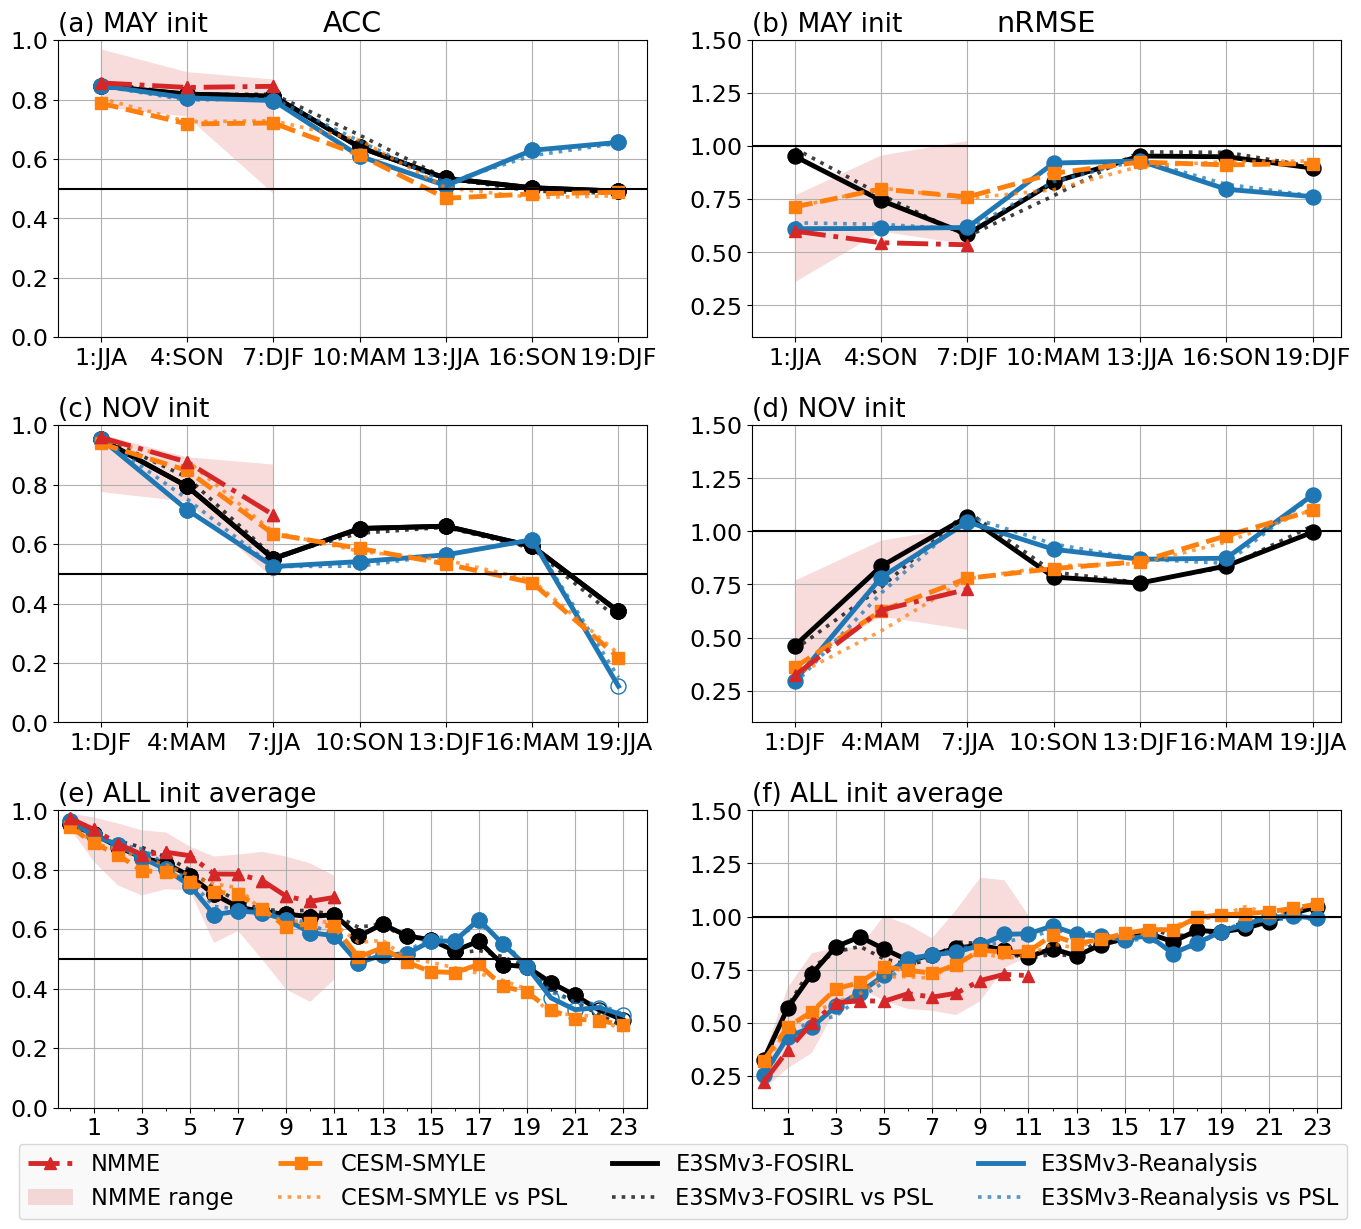

In [186]:
# -----------------------------
# Plot skill scores
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
field = cfg.region_name
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, f"{cfg.region_name.lower()}_acc_skill", ext=figfmt)
dpi = 300
save_bbox = "tight"

startmonths_requested = cfg.init_months
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
header_fontz = fontz * 1.15
tick_fontz = fontz * 0.95
legend_fontz = fontz * 0.90

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
marker_size = fontz * 0.6
e3sm_marker_size = marker_size
smyle_marker_size = marker_size * 0.75

# E3SM case labels and colors come from E3SM_CASES config
e3sm_label = E3SM_CASES[E3SM_REFERENCE_CASE]["display_name"]
e3sm_color  = E3SM_CASES[E3SM_REFERENCE_CASE]["color"]  # used for PSL dotted lines
smyle_label = "CESM-SMYLE"
smyle_color = "tab:orange"
nmme_color = "tab:red"
smyle_linestyle = "--"
nmme_linestyle = "-."
nmme_marker = "^"
nmme_marker_size = marker_size * 0.75
nmme_spread_alpha = 0.16
psl_linestyle = ":"
psl_alpha = 0.75
psl_line_width = line_width * 0.75
e3sm_marker = "o"
smyle_marker = "s"
significance_pval = 0.1
open_marker_fillstyle = "none"
marker_only_linestyle = "none"

hindcast_label = {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"}
all_init_label = "ALL init average"
figlab_fmt = "({})"

season_labels_by_month = {
    2:  ["MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF"],
    5:  ["JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM"],
    8:  ["SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA"],
    11: ["DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON"],
}

seasonal_xlim = [-0.5, 20]
monthly_xlim = [-0.5, 24]
acc_ylim = plot_settings["acc_lim"]
seasonal_rmse_ylim = plot_settings["rmse_lim"]
monthly_rmse_ylim = plot_settings["rmse_lim"]
acc_hline = 0.5
rmse_hline = 1.0
hline_color = "black"
show_grid = True
acc_header = "ACC"
rmse_header = "nRMSE"
acc_yticks = np.arange(10) * 0.1 + 0.1
acc_yticklabels = ["0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", ""]
rmse_yticks = np.arange(12) * 0.1 + 0.2
rmse_yticklabels = ["0.2", "", "0.4", "", "0.6", "", "0.8", "", "1.0", "", "1.2", ""]
monthly_xticks = np.arange(12) * 2 + 1
monthly_xticks_minor = np.arange(12) * 2
legend_locs = {"acc": "lower left", "rmse": "upper right"}

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

# -----------------------------
# Derived plot values
# -----------------------------
leadsea = e3smle_seas_skill.L - 2
_nlead_seas = leadsea.sizes["L"]
xsea = {
    month: labels[:_nlead_seas]
    for month, labels in season_labels_by_month.items()
}
startmonths = [
    m for m in startmonths_requested
    if m in e3smle_seas_skill.startmonth.values
]
nrow = len(startmonths) + 1
fig = plt.figure(figsize=(fig_width, row_height * nrow))
figlabs = [figlab_fmt.format(chr(97 + i)) for i in range(nrow * ncol)]

# -----------------------------
# Seasonal skill panels by initialization month
# -----------------------------
for j, sm in enumerate(startmonths):
    sm_int = int(sm)
    ax = fig.add_subplot(nrow, ncol, j * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, j * 2 + 2)

    label = hindcast_label.get(sm_int, f"{sm_int:02d} init")

    ax.set_title(figlabs[j * 2] + " " + label, loc="left", fontsize=title_fontz)
    ax2.set_title(figlabs[j * 2 + 1] + " " + label, loc="left", fontsize=title_fontz)

    if j == 0:
        ax.set_title(acc_header, loc="center", fontsize=header_fontz)
        ax2.set_title(rmse_header, loc="center", fontsize=header_fontz)

    tmp = e3smle_seas_skill.sel(startmonth=sm)

    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
    for case_key, case_info in E3SM_ACTIVE_CASES.items():
        if case_key not in e3smle_seas_skill_by_case:
            continue
        case_color    = case_info["color"]
        case_label    = case_info["display_name"]
        case_ls       = case_info.get("linestyle", "-")
        tmp = e3smle_seas_skill_by_case[case_key].sel(startmonth=sm)
        ax.plot(tmp.L - 2, tmp.corr, color=case_color, linewidth=line_width, linestyle=case_ls, label=case_label)
        ax.plot(tmp.L - 2, tmp.corr, color=case_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
        ax.plot(tmp.L - 2, tmp.corr.where(tmp.pval < significance_pval), color=case_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

        ax2.plot(tmp.L - 2, tmp.rmse, color=case_color, linewidth=line_width, linestyle=case_ls, marker=e3sm_marker, markersize=e3sm_marker_size, label=case_label)

        if (
            case_key in e3smle_seas_skill_ref_by_case
            and "reference" in e3smle_seas_skill_ref_by_case[case_key].coords
            and "PSL" in e3smle_seas_skill_ref_by_case[case_key].reference.values
            and sm in e3smle_seas_skill_ref_by_case[case_key].startmonth.values
        ):
            tmp_psl = e3smle_seas_skill_ref_by_case[case_key].sel(startmonth=sm, reference="PSL")
            ax.plot(
                tmp_psl.L - 2,
                tmp_psl.corr,
                color=case_color,
                linewidth=psl_line_width,
                linestyle=psl_linestyle,
                alpha=psl_alpha,
            )
            ax2.plot(
                tmp_psl.L - 2,
                tmp_psl.rmse,
                color=case_color,
                linewidth=psl_line_width,
                linestyle=psl_linestyle,
                alpha=psl_alpha,
            )

    if "smyle_seas_skill_plot" in globals() and sm in smyle_seas_skill_plot.startmonth.values:
        tmp_smyle = smyle_seas_skill_plot.sel(startmonth=sm)
        ax.plot(
            tmp_smyle.L - 2,
            tmp_smyle.corr,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )
        ax2.plot(
            tmp_smyle.L - 2,
            tmp_smyle.rmse,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )

    if (
        "smyle_seas_skill_ref" in globals()
        and "reference" in smyle_seas_skill_ref.coords
        and "PSL" in smyle_seas_skill_ref.reference.values
        and sm in smyle_seas_skill_ref.startmonth.values
    ):
        tmp_smyle_psl = smyle_seas_skill_ref.sel(startmonth=sm, reference="PSL")
        ax.plot(
            tmp_smyle_psl.L - 2,
            tmp_smyle_psl.corr,
            color=smyle_color,
            linewidth=psl_line_width,
            linestyle=psl_linestyle,
            alpha=psl_alpha,
        )
        ax2.plot(
            tmp_smyle_psl.L - 2,
            tmp_smyle_psl.rmse,
            color=smyle_color,
            linewidth=psl_line_width,
            linestyle=psl_linestyle,
            alpha=psl_alpha,
        )

    if "nmme_seas_skill_plot" in globals() and sm in nmme_seas_skill_plot.startmonth.values:
        tmp_nmme = nmme_seas_skill_plot.sel(startmonth=sm)
        ax.plot(
            tmp_nmme.L - 2,
            tmp_nmme.corr,
            color=nmme_color,
            linewidth=line_width,
            linestyle=nmme_linestyle,
            marker=nmme_marker,
            markersize=nmme_marker_size,
            label=nmme_label,
        )
        ax.plot(
            tmp_nmme.L - 2,
            tmp_nmme.corr.where(tmp_nmme.pval < significance_pval),
            color=nmme_color,
            marker=nmme_marker,
            markersize=nmme_marker_size,
            linestyle=marker_only_linestyle,
        )
        ax2.plot(
            tmp_nmme.L - 2,
            tmp_nmme.rmse,
            color=nmme_color,
            linewidth=line_width,
            linestyle=nmme_linestyle,
            marker=nmme_marker,
            markersize=nmme_marker_size,
            label=nmme_label,
        )

        if "nmme_seas_skill_spread" in globals() and sm in nmme_seas_skill_spread.startmonth.values:
            # Seasonal red line is start-month-specific; draw the envelope
            # across selected start months and models so the NMME range remains visible.
            tmp_nmme_spread = nmme_seas_skill_spread
            nmme_seas_spread_dims = [
                dim for dim in ("startmonth", "model") if dim in tmp_nmme_spread.dims
            ]
            ax.fill_between(
                tmp_nmme_spread.L.data - 2,
                tmp_nmme_spread.corr.min(nmme_seas_spread_dims, skipna=True),
                tmp_nmme_spread.corr.max(nmme_seas_spread_dims, skipna=True),
                fc=nmme_color,
                alpha=nmme_spread_alpha,
                linewidth=0,
            )
            ax2.fill_between(
                tmp_nmme_spread.L.data - 2,
                tmp_nmme_spread.rmse.min(nmme_seas_spread_dims, skipna=True),
                tmp_nmme_spread.rmse.max(nmme_seas_spread_dims, skipna=True),
                fc=nmme_color,
                alpha=nmme_spread_alpha,
                linewidth=0,
            )

    xticklabs = [f"{int(leadsea[i].data)}:{xsea[sm_int][i]}" for i in range(_nlead_seas)]

    ax.set_xticks(leadsea)
    ax.set_xticklabels(xticklabs, fontsize=tick_fontz)
    # ax.set_yticks(acc_yticks)
    # ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
    ax.set_xlim(seasonal_xlim)
    ax.set_ylim(acc_ylim)
    ax.tick_params(axis="both", labelsize=tick_fontz)
    ax.grid(show_grid)
    ax.axhline(y=acc_hline, color=hline_color)

    ax2.set_xticks(leadsea)
    ax2.set_xticklabels(xticklabs, fontsize=tick_fontz)
    # ax2.set_yticks(rmse_yticks)
    # ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
    ax2.set_xlim(seasonal_xlim)
    ax2.set_ylim(seasonal_rmse_ylim)
    ax2.tick_params(axis="both", labelsize=tick_fontz)
    ax2.grid(show_grid)
    ax2.axhline(y=rmse_hline, color=hline_color)

    # if j == 0:
    #     ax.legend(loc=legend_locs["acc"], fontsize=legend_fontz)
    #     ax2.legend(loc=legend_locs["rmse"], fontsize=legend_fontz)

# -----------------------------
# Monthly ALL-init average panels
# -----------------------------
bottom_row = len(startmonths)
ax = fig.add_subplot(nrow, ncol, bottom_row * 2 + 1)
ax2 = fig.add_subplot(nrow, ncol, bottom_row * 2 + 2)

ax.set_title(figlabs[bottom_row * 2] + " " + all_init_label, loc="left", fontsize=title_fontz)
ax2.set_title(figlabs[bottom_row * 2 + 1] + " " + all_init_label, loc="left", fontsize=title_fontz)
for case_key, case_info in E3SM_ACTIVE_CASES.items():
    if case_key not in e3smle_skill_by_case:
        continue
    case_color = case_info["color"]
    case_label = case_info["display_name"]
    case_ls    = case_info.get("linestyle", "-")
    tmp = e3smle_skill_by_case[case_key].mean("startmonth")

    ax.plot(tmp.L - 1, tmp.corr, color=case_color, linewidth=line_width, linestyle=case_ls, label=case_label)
    ax.plot(tmp.L - 1, tmp.corr, color=case_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
    ax.plot(tmp.L - 1, tmp.corr.where(tmp.pval < significance_pval), color=case_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

    ax2.plot(tmp.L - 1, tmp.rmse, color=case_color, linewidth=line_width, linestyle=case_ls, marker=e3sm_marker, markersize=e3sm_marker_size, label=case_label)

    if (
        case_key in e3smle_skill_ref_by_case
        and "reference" in e3smle_skill_ref_by_case[case_key].coords
        and "PSL" in e3smle_skill_ref_by_case[case_key].reference.values
    ):
        tmp_psl = e3smle_skill_ref_by_case[case_key].sel(reference="PSL").mean("startmonth")
        ax.plot(
            tmp_psl.L - 1,
            tmp_psl.corr,
            color=case_color,
            linewidth=psl_line_width,
            linestyle=psl_linestyle,
            alpha=psl_alpha,
            label=f"{case_label} vs PSL",
        )
        ax2.plot(
            tmp_psl.L - 1,
            tmp_psl.rmse,
            color=case_color,
            linewidth=psl_line_width,
            linestyle=psl_linestyle,
            alpha=psl_alpha,
            label=f"{case_label} vs PSL",
        )

if "smyle_skill_plot" in globals():
    # Bottom panels are monthly ALL-init averages, so use monthly CESM-SMYLE skill.
    tmp_smyle = smyle_skill_plot.mean("startmonth")
    ax.plot(
        tmp_smyle.L - 1,
        tmp_smyle.corr,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )
    ax2.plot(
        tmp_smyle.L - 1,
        tmp_smyle.rmse,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )

if (
    "smyle_skill_ref" in globals()
    and "reference" in smyle_skill_ref.coords
    and "PSL" in smyle_skill_ref.reference.values
):
    tmp_smyle_psl = smyle_skill_ref.sel(reference="PSL").mean("startmonth")
    ax.plot(
        tmp_smyle_psl.L - 1,
        tmp_smyle_psl.corr,
        color=smyle_color,
        linewidth=psl_line_width,
        linestyle=psl_linestyle,
        alpha=psl_alpha,
        label=f"{smyle_label} vs PSL",
    )
    ax2.plot(
        tmp_smyle_psl.L - 1,
        tmp_smyle_psl.rmse,
        color=smyle_color,
        linewidth=psl_line_width,
        linestyle=psl_linestyle,
        alpha=psl_alpha,
        label=f"{smyle_label} vs PSL",
    )

# Bottom panels are monthly ALL-init averages, so use monthly-lead NMME skill here.
if "nmme_skill_plot" in globals():
    tmp_nmme = nmme_skill_plot.mean("startmonth")
    ax.plot(
        tmp_nmme.L - 1,
        tmp_nmme.corr,
        color=nmme_color,
        linewidth=line_width,
        linestyle=nmme_linestyle,
        marker=nmme_marker,
        markersize=nmme_marker_size,
        label=nmme_label,
    )
    ax.plot(
        tmp_nmme.L - 1,
        tmp_nmme.corr.where(tmp_nmme.pval < significance_pval),
        color=nmme_color,
        marker=nmme_marker,
        markersize=nmme_marker_size,
        linestyle=marker_only_linestyle,
    )
    ax2.plot(
        tmp_nmme.L - 1,
        tmp_nmme.rmse,
        color=nmme_color,
        linewidth=line_width,
        linestyle=nmme_linestyle,
        marker=nmme_marker,
        markersize=nmme_marker_size,
        label=nmme_label,
    )

    if "nmme_skill_spread" in globals():
        # Keep the line as the ALL-init monthly MMM, but draw the envelope
        # across both start months and models so the band does not collapse.
        tmp_nmme_spread = nmme_skill_spread
        nmme_spread_dims = [dim for dim in ("startmonth", "model") if dim in tmp_nmme_spread.dims]
        ax.fill_between(
            tmp_nmme_spread.L.data - 1,
            tmp_nmme_spread.corr.min(nmme_spread_dims, skipna=True),
            tmp_nmme_spread.corr.max(nmme_spread_dims, skipna=True),
            fc=nmme_color,
            alpha=nmme_spread_alpha,
            linewidth=0,
        )
        ax2.fill_between(
            tmp_nmme_spread.L.data - 1,
            tmp_nmme_spread.rmse.min(nmme_spread_dims, skipna=True),
            tmp_nmme_spread.rmse.max(nmme_spread_dims, skipna=True),
            fc=nmme_color,
            alpha=nmme_spread_alpha,
            linewidth=0,
        )

ax.set_xticks(monthly_xticks)
ax.set_xticks(monthly_xticks_minor, minor=True)
ax.tick_params(axis="both", labelsize=tick_fontz)
    # ax.set_yticks(acc_yticks)
    # ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
ax.set_xlim(monthly_xlim)
ax.set_ylim(acc_ylim)
ax.grid(show_grid)
ax.axhline(y=acc_hline, color=hline_color)

ax2.set_xticks(monthly_xticks)
ax2.set_xticks(monthly_xticks_minor, minor=True)
ax2.tick_params(axis="both", labelsize=tick_fontz)
    # ax2.set_yticks(rmse_yticks)
    # ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
ax2.set_xlim(monthly_xlim)
ax2.set_ylim(monthly_rmse_ylim)
ax2.grid(show_grid)
ax2.axhline(y=rmse_hline, color=hline_color)

# Collect handles and labels for a single legend at the bottom.
# Pair each primary system with its PSL sensitivity entry when available.
handles, labels = ax.get_legend_handles_labels()
if "nmme_skill_spread" in globals() and nmme_label in labels:
    handles.append(mpatches.Patch(facecolor=nmme_color, alpha=nmme_spread_alpha, linewidth=0))
    labels.append("NMME range")

preferred_legend_order = [
    nmme_label,
    "NMME range",
    smyle_label,
]
legend_items = {}
for handle, label in zip(handles, labels):
    if label and label not in legend_items:
        legend_items[label] = handle
base_labels = [
    label for label in legend_items
    if " vs PSL" not in label and label != "NMME range"
]
ordered_labels = []
for label in preferred_legend_order + [label for label in base_labels if label not in preferred_legend_order]:
    if label in legend_items and label not in ordered_labels:
        ordered_labels.append(label)
    psl_label = f"{label} vs PSL"
    if psl_label in legend_items and psl_label not in ordered_labels:
        ordered_labels.append(psl_label)
ordered_labels += [label for label in legend_items if label not in ordered_labels]
handles = [legend_items[label] for label in ordered_labels]
labels = ordered_labels
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="lightgray",
    framealpha=0.9
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric=f"{cfg.region_name.lower()}_sst_skill",
    dpi=dpi,

)
print("Saved figure:", figpath)
plt.show()

In [187]:
# -----------------------------
# DJF observed anomaly series
# -----------------------------
print(obs_seas.time)

jan = obs_seas.time.dt.month == 1
obs_djf = obs_seas.where(jan).dropna("time")
obs_djf = obs_djf - obs_djf.sel(time=slice(str(climy0), str(climy1))).mean("time")

psl_djf = psl_seas.where(psl_seas.time.dt.month == 1).dropna("time")

<xarray.DataArray 'time' (time: 1846)> Size: 15kB
array([cftime.DatetimeNoLeap(1869, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 3, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 4, 15, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2022, 9, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 10, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 11, 15, 0, 0, 0, 0, has_year_zero=True)],
      shape=(1846,), dtype=object)
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00


In [188]:
# -----------------------------
# Combine seasonal drift-corrected series (all cases)
# (order follows cfg.init_months)
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

e3smle_seas_by_case      = {}
e3smle_seas_time_by_case = {}
e3smle_seas_skill_plot_by_case     = {}
e3smle_seas_skill_ref_plot_by_case = {}

for case_key in E3SM_ACTIVE_CASES:
    case_results    = results_by_case[case_key]
    case_results_dd = results_dd_by_case[case_key]
    case_skill      = results_skill_by_case[case_key]

    e3smle_seas_by_case[case_key] = xr.concat(
        [case_results_dd[m]["seas_dd"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_seas_time_by_case[case_key] = xr.concat(
        [case_results[m]["time_seas"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_seas_skill_plot_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_seas"] for m in cfg.init_months], dim=startmonth
    )
    e3smle_seas_skill_ref_plot_by_case[case_key] = xr.concat(
        [case_skill[m]["skill_ref_seas"] for m in cfg.init_months], dim=startmonth
    )

# Backward-compatible reference-case aliases
e3smle_seas           = e3smle_seas_by_case[E3SM_REFERENCE_CASE]
e3smle_seas_time      = e3smle_seas_time_by_case[E3SM_REFERENCE_CASE]
e3smle_seas_skill_plot     = e3smle_seas_skill_plot_by_case[E3SM_REFERENCE_CASE]
e3smle_seas_skill_ref_plot = e3smle_seas_skill_ref_plot_by_case[E3SM_REFERENCE_CASE]

print(e3smle_seas)
print(e3smle_seas_time)
print(e3smle_seas_skill_plot)


<xarray.DataArray 'sst' (startmonth: 2, Y: 78, L: 8, M: 10)> Size: 100kB
array([[[[ 1.78887273,  0.98183245,  1.58266801, ...,  1.75685482,
           1.73213785,  1.13079308],
         [ 2.1134412 , -0.12422353,  1.9072849 , ...,  2.23293516,
           2.4103891 ,  0.9293722 ],
         [ 1.75089081, -0.09270704,  1.4675236 , ...,  1.0123004 ,
           1.61220655,  0.70729162],
         ...,
         [-0.30820905,  0.01784086, -0.21139189, ..., -0.12517167,
          -0.63652211,  1.74664126],
         [-0.58818052,  0.3052841 ,  0.08953932, ..., -0.88447231,
          -0.72140392,  1.98544824],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
            

/tmp/ipykernel_685380/3683956681.py:17: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas_by_case[case_key] = xr.concat(
/tmp/ipykernel_685380/3683956681.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas_time_by_case[case_key] = xr.concat(
/tmp/ipykernel_685380/3683956681.py:17: FutureWarning: In a future version of xarray the default value for jo

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nino3_4_nino3_4_time_series.png


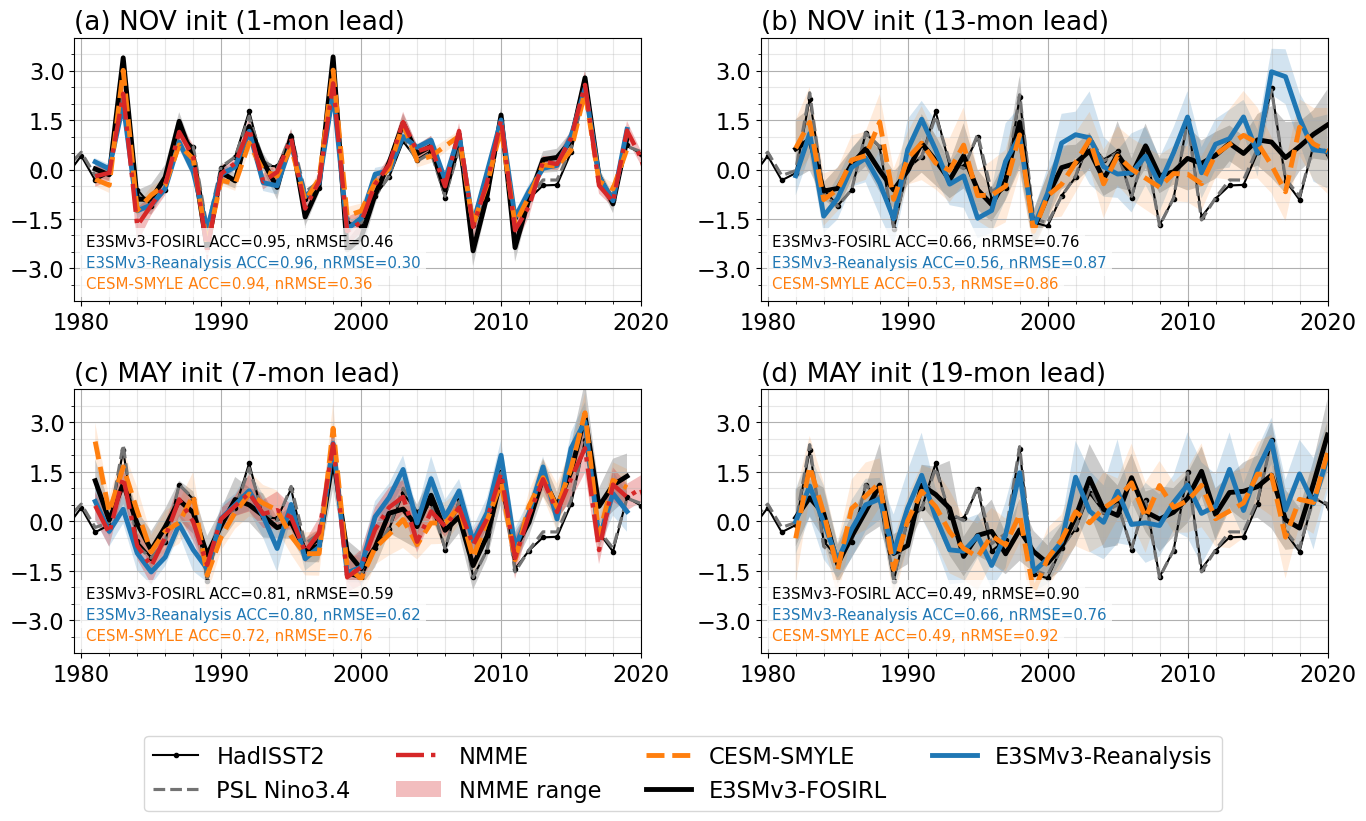

In [189]:
# -----------------------------
# Plot DJF SST-index time series
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
startmonths_requested = [11, 5]
djf_leads = {
    11: [3, 15],   # NOV init
    5: [9, 21],    # MAY init
}
startmonths_plot = [m for m in startmonths_requested if m in e3smle_seas.startmonth.values]
nrow = len(startmonths_plot)
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
tick_fontz = fontz * 0.9
legend_fontz = fontz * 0.9
annotation_fontz = fontz * 1.2 / len(E3SM_ACTIVE_CASES)

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
obs_marker_size = 6
e3sm_spread_alpha = 0.2
smyle_spread_alpha = 0.15
nmme_color = "tab:red"
nmme_linestyle = "-."
nmme_spread_alpha = 0.30
grid_minor_alpha = 0.3
annotation_box = dict(facecolor="white", alpha=0.75, edgecolor="none")
e3sm_annotation_xy = (0.02, 0.13)
smyle_annotation_xy = (0.02, 0.05)

plot_ylim = plot_settings["ts_lim"]
major_yticks = plot_settings["ts_yticks"]
minor_yticks = np.arange(plot_ylim[0] + 0.5, plot_ylim[1], 0.5)
plot_xmin = 1979.5
plot_xmax = 2020.0
major_years = [1980, 1990, 2000, 2010, 2020]
minor_years = np.arange(1980, 2021, 2)

hindcast_label = {11: "NOV", 5: "MAY"}
hindcast_color = {11: "g", 5: "b"}
# E3SM case labels/colors come from E3SM_CASES config
e3sm_label = E3SM_CASES[E3SM_REFERENCE_CASE]["display_name"]
smyle_color = "tab:orange"
obs_color = "k"
psl_obs_color = "0.45"
psl_obs_linestyle = "--"
figlabs = [["(a)", "(c)"], ["(b)", "(d)"]]
field = cfg.region_name
psl_obs_label = "PSL DMI" if cfg.region_name == "IOD" else f"PSL {cfg.region_name}"
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, f"{cfg.region_name.lower()}_time_series", ext=figfmt)
dpi = 300
legend_bbox_to_anchor = (0.5, 0.0)
tight_layout_rect = [0, 0.13, 1, 1]

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})
fig = plt.figure(figsize=(fig_width, row_height * nrow))

def _time_part_values(time_da, part, drop_missing=False):
    values = np.asarray(time_da.values).ravel()
    out = []

    for t in values:
        value = np.nan
        try:
            if t is not None:
                if hasattr(t, part):
                    value = getattr(t, part)
                else:
                    ts = pd.Timestamp(t)
                    if not pd.isna(ts):
                        value = getattr(ts, part)
        except (TypeError, ValueError, OverflowError):
            value = np.nan

        out.append(value)

    arr = np.asarray(out, dtype=float)
    if drop_missing:
        arr = arr[np.isfinite(arr)]
    return arr

def _year_values(time_da):
    return _time_part_values(time_da, "year")

if "M" in e3smle_seas.dims:
    member_dim = "M"
elif "member" in e3smle_seas.dims:
    member_dim = "member"
else:
    member_dim = None


for i, sm in enumerate(startmonths_plot):
    ax = fig.add_subplot(nrow, ncol, i * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, i * 2 + 2)

    for a in [ax, ax2]:
        a.set_ylim(plot_ylim)
        a.set_yticks(major_yticks)
        a.set_yticks(minor_yticks, minor=True)

        # x-axis like the reference figure
        a.set_xlim([plot_xmin, plot_xmax])
        a.set_xticks(major_years)
        a.set_xticks(minor_years, minor=True)
        a.tick_params(axis="both", labelsize=tick_fontz)

        a.plot(
            obs_djf.time.dt.year,
            obs_djf,
            color=obs_color,
            marker=".",
            markersize=obs_marker_size,
            label="HadISST2",
        )

        if "psl_djf" in globals():
            a.plot(
                psl_djf.time.dt.year,
                psl_djf,
                color=psl_obs_color,
                linestyle=psl_obs_linestyle,
                linewidth=line_width * 0.65,
                label=psl_obs_label,
            )

        a.grid(True, which="major")
        a.grid(True, which="minor", alpha=grid_minor_alpha)

    for col_idx, (ax_panel, target_L) in enumerate(zip([ax, ax2], djf_leads[sm])):

        available_L = e3smle_seas.sel(startmonth=sm).L.values
        if target_L not in available_L:
            ax_panel.set_title(f"L={target_L} not available", loc="left", fontsize=title_fontz)
            continue

        data = e3smle_seas.sel(startmonth=sm, L=target_L)
        tmp_time = e3smle_seas_time.sel(startmonth=sm, L=target_L)
        skill_row = e3smle_seas_skill_plot.sel(startmonth=sm, L=target_L)

        # Use reference case for validity check and title
        valid_months = _time_part_values(tmp_time, "month", drop_missing=True)
        if valid_months.size and not np.all(valid_months == 1):
            raise ValueError(
                f"Expected DJF center month January for startmonth={sm}, L={target_L}; "
                f"found months {np.unique(valid_months)}"
            )

        lead = int(target_L) - 2
        titl = f"{hindcast_label[sm]} init ({lead}-mon lead)"
        figlabel = figlabs[col_idx][i]
        ax_panel.set_title(figlabel + " " + titl, loc="left", fontsize=title_fontz)

        # Plot all E3SM cases
        n_e3sm_cases = len(E3SM_ACTIVE_CASES)
        # Annotation y positions: stack downward from top, SMYLE stays at 0.05
        annot_y_step = 0.08
        annot_y_top  = 0.05 + annot_y_step * n_e3sm_cases

        for ci, (case_key, case_info) in enumerate(E3SM_CASES.items()):
            if case_key not in e3smle_seas_by_case:
                continue
            if sm not in e3smle_seas_by_case[case_key].startmonth.values:
                continue
            if target_L not in e3smle_seas_by_case[case_key].sel(startmonth=sm).L.values:
                continue

            case_color = case_info["color"]
            case_label = case_info["display_name"]
            case_ls    = case_info.get("linestyle", "-")
            annot_y    = annot_y_top - annot_y_step * ci
            color=hindcast_color[sm],
            case_data       = e3smle_seas_by_case[case_key].sel(startmonth=sm, L=target_L)
            case_tmp_time   = e3smle_seas_time_by_case[case_key].sel(startmonth=sm, L=target_L)
            case_skill_row  = e3smle_seas_skill_plot_by_case[case_key].sel(startmonth=sm, L=target_L)

            case_acc   = float(case_skill_row.corr.values)
            case_nrmse = float(case_skill_row.rmse.values)

            case_datatime = _year_values(case_tmp_time)
            case_valid    = np.isfinite(case_datatime)
            case_datatime_plot = case_datatime[case_valid]
            case_data_plot     = case_data.isel(Y=case_valid)

            _mdim = "M" if "M" in case_data_plot.dims else ("member" if "member" in case_data_plot.dims else None)
            case_datamean = case_data_plot.mean(_mdim) if _mdim else case_data_plot
            case_datastd  = case_data_plot.std(_mdim)  if _mdim else xr.zeros_like(case_data_plot)
            ax_panel.plot(
                case_datatime_plot,
                case_datamean,
                color=case_color,
                linewidth=line_width,
                linestyle=case_ls,
                label=case_label,
            )
            ax_panel.fill_between(
                case_datatime_plot,
                (case_datamean - case_datastd).values,
                (case_datamean + case_datastd).values,
                fc=case_color,
                alpha=e3sm_spread_alpha,
            )

            ax_panel.text(
                0.02, annot_y,
                f"{case_label} ACC={case_acc:3.2f}, nRMSE={case_nrmse:3.2f}",
                transform=ax_panel.transAxes,
                fontsize=annotation_fontz,
                color=case_color,
                bbox=annotation_box,
            )

        # Optional CESM-SMYLE overlay for the same initialization month and DJF lead.
        if (
            "smyle_seas" in globals()
            and "smyle_seas_time" in globals()
            and sm in smyle_seas.startmonth.values
            and target_L in smyle_seas.sel(startmonth=sm).L.values
        ):
            smyle_data = smyle_seas.sel(startmonth=sm, L=target_L)
            smyle_tmp_time = smyle_seas_time.sel(startmonth=sm, L=target_L)

            smyle_datatime = _year_values(smyle_tmp_time)
            smyle_valid = np.isfinite(smyle_datatime)
            smyle_datatime_plot = smyle_datatime[smyle_valid]
            smyle_data_plot = smyle_data.isel(Y=smyle_valid)

            if "M" in smyle_data_plot.dims:
                smyle_member_dim = "M"
            elif "member" in smyle_data_plot.dims:
                smyle_member_dim = "member"
            else:
                smyle_member_dim = None

            if smyle_member_dim is not None:
                smyle_mean = smyle_data_plot.mean(smyle_member_dim)
                smyle_std = smyle_data_plot.std(smyle_member_dim)
            else:
                smyle_mean = smyle_data_plot
                smyle_std = xr.zeros_like(smyle_data_plot)
            ax_panel.plot(
                smyle_datatime_plot,
                smyle_mean,
                color=smyle_color,
                linewidth=line_width,
                linestyle="--",
                label="CESM-SMYLE",
            )

            ax_panel.fill_between(
                smyle_datatime_plot,
                (smyle_mean - smyle_std).values,
                (smyle_mean + smyle_std).values,
                fc=smyle_color,
                alpha=smyle_spread_alpha,
            )
            "nmme_seas" in globals()
            if (
                "smyle_seas_skill_plot" in globals()
                and sm in smyle_seas_skill_plot.startmonth.values
                and target_L in smyle_seas_skill_plot.sel(startmonth=sm).L.values
            ):
                smyle_skill_row = smyle_seas_skill_plot.sel(startmonth=sm, L=target_L)
                smyle_acc = float(smyle_skill_row.corr.values)
                smyle_nrmse = float(smyle_skill_row.rmse.values)
                ax_panel.text(
                    *smyle_annotation_xy,
                    f"CESM-SMYLE ACC={smyle_acc:3.2f}, nRMSE={smyle_nrmse:3.2f}",
                    transform=ax_panel.transAxes,
                    fontsize=annotation_fontz,
                    color=smyle_color,
                    bbox=annotation_box,
                )
        # Optional NMME overlay for Nino3.4. The current NMME archive has 12 monthly
        # leads, so only DJF panels whose seasonal lead exists are plotted.
        if (
            "nmme_seas" in globals()
            and "nmme_seas_time" in globals()
            and sm in nmme_seas.startmonth.values
            and target_L in nmme_seas.sel(startmonth=sm).L.values
        ):
            nmme_data = nmme_seas.sel(startmonth=sm, L=target_L)
            nmme_tmp_time = nmme_seas_time.sel(startmonth=sm, L=target_L)

            nmme_datatime = _year_values(nmme_tmp_time)
            nmme_valid = np.isfinite(nmme_datatime)
            nmme_datatime_plot = nmme_datatime[nmme_valid]
            nmme_data_plot = nmme_data.isel(Y=nmme_valid)

            if "M" in nmme_data_plot.dims and "model" in nmme_data_plot.dims:
                nmme_model_mean = nmme_data_plot.mean("M", skipna=True)
                nmme_mean = nmme_model_mean.mean("model", skipna=True)
                nmme_std = nmme_model_mean.std("model", skipna=True)
            elif "model" in nmme_data_plot.dims:
                nmme_mean = nmme_data_plot.mean("model", skipna=True)
                nmme_std = nmme_data_plot.std("model", skipna=True)
            elif "M" in nmme_data_plot.dims:
                nmme_mean = nmme_data_plot.mean("M", skipna=True)
                nmme_std = nmme_data_plot.std("M", skipna=True)
            else:
                nmme_mean = nmme_data_plot
                nmme_std = xr.zeros_like(nmme_data_plot)
# Collect unique handles and labels for a single 1-line legend at the bottom.
            ax_panel.plot(
                nmme_datatime_plot,
                nmme_mean,
                color=nmme_color,
                linewidth=line_width * 0.9,
                linestyle=nmme_linestyle,
                label=nmme_label,
            )

            ax_panel.fill_between(
                nmme_datatime_plot,
                (nmme_mean - nmme_std).values,
                (nmme_mean + nmme_std).values,
                fc=nmme_color,
                alpha=nmme_spread_alpha,
            )

        # if i == 0 and col_idx == 0:
        #     ax_panel.legend(loc="upper right", fontsize=legend_fontz)

# Collect unique handles and labels for a single legend at the bottom.
# Some optional overlays are only available on a subset of panels.
handles = []
labels = []
seen_labels = set()
for axis in fig.axes:
    axis_handles, axis_labels = axis.get_legend_handles_labels()
    for handle, label in zip(axis_handles, axis_labels):
        if label and label not in seen_labels:
            handles.append(handle)
            labels.append(label)
            seen_labels.add(label)

if nmme_label in seen_labels:
    handles.append(mpatches.Patch(facecolor=nmme_color, alpha=nmme_spread_alpha, linewidth=0))
    labels.append("NMME range")

reference_legend_labels = ["HadISST2", psl_obs_label]
preferred_legend_order = reference_legend_labels + [nmme_label, "NMME range", "CESM-SMYLE"]
legend_items = {}
for handle, label in zip(handles, labels):
    if label and label not in legend_items:
        legend_items[label] = handle
ordered_labels = [label for label in preferred_legend_order if label in legend_items]
ordered_labels += [label for label in legend_items if label not in ordered_labels]
handles = [legend_items[label] for label in ordered_labels]
labels = ordered_labels

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=legend_bbox_to_anchor,
    edgecolor="lightgray",
    framealpha=0.9,
)

fig.tight_layout(rect=tight_layout_rect)
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig,
    figpath,
    mode="",
    metric=f"{cfg.region_name.lower()}_sst_time_series",
    title=f"{cfg.region_name} SST Time Series: {field}",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


In [190]:
# -----------------------------
# Clean up Dask resources
# -----------------------------
close_cluster(cluster, client)

2026-07-15 00:30:03,386 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^